In [1]:
import os
from pathlib import Path
import pickle
from matplotlib import pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from glmhmm import *
from plotting_style import *

In [2]:
# Magics
%load_ext autoreload
%autoreload 2

In [3]:
# Plotting style
style_path = os.path.expanduser('~/PycharmProjects/alexis_style.mplstyle')
plt.style.use(style_path)
%config InlineBackend.figure_format = 'svg'
# %config InlineBackend.figure_format = 'retina'
sns.set_style('ticks')
sns.set_context('notebook')

In [4]:
# Load results
path = Path.home() / 'PycharmProjects' / 'glmhmm' / 'results.pkl'
with open(path, 'rb') as f:
    results = pickle.load(f)

# Unpack results
all_animals = results['all_animals']
experiment = results['experiment']
fit_ll = results['fit_ll']
weights = results['weights']
trans_mat = results['trans_mat']
posterior_probs = results['posterior_probs']
log_likelihood = results['log_likelihood']
# remap_indices = results['remap_indices']
drug = results['drug']
interpret = results['interpret']

data = results_2_df(all_animals, experiment, weights)

# Mean groups 2-4

Covariate 0: t=8.707, p=0.0000
Covariate 1: t=-3.175, p=0.0041
Covariate 2: t=-3.480, p=0.0019


<Axes: title={'center': 'GLM-HMM kernel'}, ylabel='Weight'>

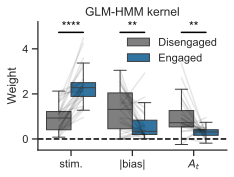

In [5]:
figsize = fig_size(n_cols=2)
mask = data.Experiment.isin(['2AFC_2', '2AFC_3', '2AFC_4'])
plot_paired_boxplot_GLMHMM_kernel(data[mask], drug=False, figsize=figsize, loc='upper right',  bbox_to_anchor=(1, 0.95))

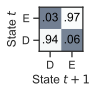

In [6]:
figsize = (fig_size(n_cols=2)[1]/2, fig_size(n_cols=2)[1]/2)
plot_trans_mat(trans_mat[:-10], figsize=figsize)

State 0 occupancy: 0.29
State 1 occupancy: 0.71


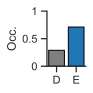

In [7]:
figsize = (fig_size(n_cols=2)[1]/2, fig_size(n_cols=2)[1]/2)
plot_occupancy(posterior_probs[:-10], figsize=figsize)

Log likelihood (normalized by number of trials): -0.66 ± 0.09 (mean ± SD across subjects)


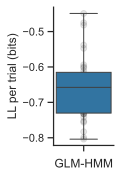

In [8]:
figsize = (fig_size(n_cols=2)[0]/2, fig_size(n_cols=2)[1])
plot_log_likelihood(log_likelihood, posterior_probs, to_bits=True, figsize=figsize)

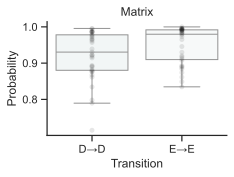

In [9]:
figsize = fig_size(n_cols=2)
plot_trans_mat_box_plots(trans_mat, figsize=figsize)

t = 7.402, p = 0.000


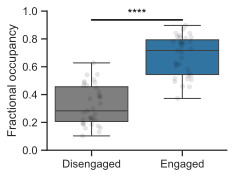

In [10]:
figsize = fig_size(n_cols=2)
plot_occupancy_boxplot(posterior_probs, figsize=figsize)

# Group 2

Mice: ['325' '326' '327' '329' '330' '332' '333' '335' '337']
Covariate 0: t=8.040, p=0.0000
Covariate 1: t=-2.204, p=0.0586
Covariate 2: t=-1.546, p=0.1606


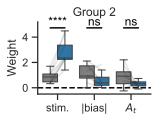

In [11]:
experiment = '2AFC_2'
figsize = fig_size(n_cols=3)
mask = data.Experiment == experiment
print(f'Mice: {data[mask].Animal.unique()}')
title = 'Group ' + experiment[-1]
ax = plot_paired_boxplot_GLMHMM_kernel(data[data.Experiment==experiment], title=title, figsize=figsize)
ax.legend_.remove()

# Group 3

Mice: ['419' '420' '422' '616' '617' '619' '623']
Covariate 0: t=3.980, p=0.0073
Covariate 1: t=-1.181, p=0.2824
Covariate 2: t=-2.326, p=0.0590


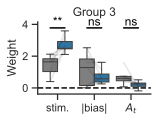

In [12]:
experiment = '2AFC_3'
figsize = fig_size(n_cols=3)
mask = data.Experiment == experiment
print(f'Mice: {data[mask].Animal.unique()}')
title = 'Group ' + experiment[-1]
ax = plot_paired_boxplot_GLMHMM_kernel(data[data.Experiment==experiment], title=title, figsize=figsize)
ax.legend_.remove()

# Group 4

Mice: ['561' '807' '820' '821' '873' '875' '907' '909' '911']
Covariate 0: t=5.485, p=0.0006
Covariate 1: t=-2.306, p=0.0500
Covariate 2: t=-2.534, p=0.0351


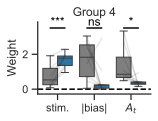

In [13]:
experiment = '2AFC_4'
figsize = fig_size(n_cols=3)
mask = data.Experiment == experiment
print(f'Mice: {data[mask].Animal.unique()}')
title = 'Group ' + experiment[-1]
ax = plot_paired_boxplot_GLMHMM_kernel(data[data.Experiment==experiment], title=title, figsize=figsize)
ax.legend_.remove()

# Group 6
Drug

## Rest
No injection (no saline nor drug)

Mice: ['014' '016' '017' '018' '019' '020' '022' '023' '024' '025']
Covariate 0: t=5.223, p=0.0005
Covariate 1: t=-0.189, p=0.8543
Covariate 2: t=-0.923, p=0.3800


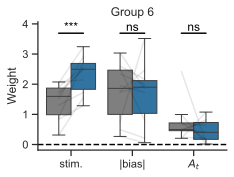

In [14]:
experiment = '2AFC_6'
figsize = fig_size(n_cols=2)
mask = data.Experiment == experiment
print(f'Mice: {data[mask].Animal.unique()}')
title = 'Group ' + experiment[-1]
ax = plot_paired_boxplot_GLMHMM_kernel(data[data.Experiment==experiment], title=title, figsize=figsize)
ax.legend_.remove()

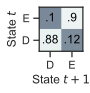

In [15]:
figsize = (fig_size(n_cols=2)[1]/2, fig_size(n_cols=2)[1]/2)
plot_trans_mat(trans_mat[-10:], figsize=figsize)

State 0 occupancy: 0.41
State 1 occupancy: 0.59


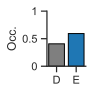

In [16]:
figsize = (fig_size(n_cols=2)[1]/2, fig_size(n_cols=2)[1]/2)
plot_occupancy(posterior_probs[-10:], figsize=figsize)

t = 1.948, p = 0.083


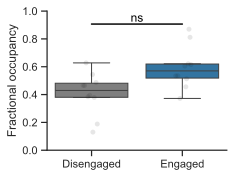

In [17]:
figsize = fig_size(n_cols=2)
plot_occupancy_boxplot(posterior_probs[-10:], figsize=figsize)

## Saline

In [18]:
# Load results
path = Path.home() / 'PycharmProjects' / 'glmhmm' / 'results_saline.pkl'
with open(path, 'rb') as f:
    results = pickle.load(f)

# Unpack results
all_animals = results['all_animals']
experiment = results['experiment']
fit_ll = results['fit_ll']
weights_saline = results['weights']
trans_mat = results['trans_mat']
posterior_probs = results['posterior_probs']
log_likelihood = results['log_likelihood']
# remap_indices = results['remap_indices']
# interpret = results['interpret']
data_saline = results_2_df(all_animals, experiment, weights_saline)

In [19]:
# Print the number of sessions in results_drug.posterior_probs
for session_probs in results['posterior_probs']:
    print(f' N sessions per subject: {len(session_probs)}')

 N sessions per subject: 7
 N sessions per subject: 9
 N sessions per subject: 10
 N sessions per subject: 5
 N sessions per subject: 4
 N sessions per subject: 11
 N sessions per subject: 10
 N sessions per subject: 9
 N sessions per subject: 9
 N sessions per subject: 9


Covariate 0: t=3.965, p=0.0033
Covariate 1: t=-0.064, p=0.9501
Covariate 2: t=-1.773, p=0.1100


Text(0.5, 1.0, 'Saline')

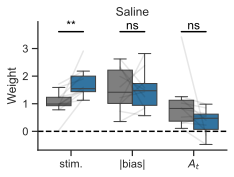

In [20]:
figsize = fig_size(n_cols=2)
ax = plot_paired_boxplot_GLMHMM_kernel(data_saline, figsize=figsize)
ax.legend_.remove()
plt.title('Saline')

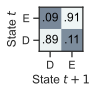

In [21]:
figsize = (fig_size(n_cols=2)[1]/2, fig_size(n_cols=2)[1]/2)
plot_trans_mat(trans_mat, figsize=figsize)

State 0 occupancy: 0.42
State 1 occupancy: 0.58


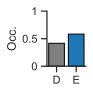

In [22]:
figsize = (fig_size(n_cols=2)[1]/2, fig_size(n_cols=2)[1]/2)
plot_occupancy(posterior_probs, figsize=figsize)

t = 2.084, p = 0.067


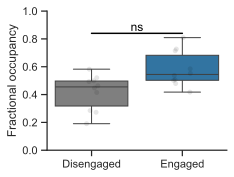

In [23]:
figsize = fig_size(n_cols=2)
plot_occupancy_boxplot(posterior_probs, figsize=figsize)

## Drug

In [24]:
# Load results
path = Path.home() / 'PycharmProjects' / 'glmhmm' / 'results_drug.pkl'
with open(path, 'rb') as f:
    results = pickle.load(f)

# Unpack results
all_animals = results['all_animals']
experiment = results['experiment']
fit_ll = results['fit_ll']
weights_drug = results['weights']
trans_mat = results['trans_mat']
posterior_probs = results['posterior_probs']
log_likelihood = results['log_likelihood']
# remap_indices = results['remap_indices']
# interpret = results['interpret']
data_drug = results_2_df(all_animals, experiment, weights_drug)

In [25]:
# Print the number of sessions in results_drug.posterior_probs
for session_probs in results['posterior_probs']:
    print(f' N sessions per subject: {len(session_probs)}')

 N sessions per subject: 7
 N sessions per subject: 9
 N sessions per subject: 10
 N sessions per subject: 5
 N sessions per subject: 4
 N sessions per subject: 11
 N sessions per subject: 9
 N sessions per subject: 9
 N sessions per subject: 9
 N sessions per subject: 9


Covariate 0: t=7.850, p=0.0000
Covariate 1: t=0.415, p=0.6879
Covariate 2: t=-2.594, p=0.0290


Text(0.5, 1.0, 'Drug')

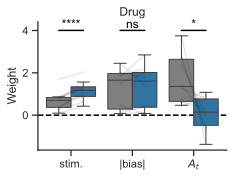

In [26]:
figsize = fig_size(n_cols=2)
ax = plot_paired_boxplot_GLMHMM_kernel(data_drug, figsize=figsize)
ax.legend_.remove()
plt.title('Drug')

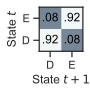

In [27]:
figsize = (fig_size(n_cols=2)[1]/2, fig_size(n_cols=2)[1]/2)
plot_trans_mat(trans_mat, figsize=figsize)

State 0 occupancy: 0.50
State 1 occupancy: 0.50


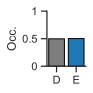

In [28]:
figsize = (fig_size(n_cols=2)[1]/2, fig_size(n_cols=2)[1]/2)
plot_occupancy(posterior_probs, figsize=figsize)

t = 0.052, p = 0.960


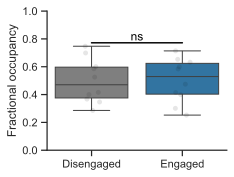

In [29]:
figsize = fig_size(n_cols=2)
plot_occupancy_boxplot(posterior_probs, figsize=figsize)

Combine data from states to compare saline vs drug

In [30]:
# Combine saline and drug data DataFrames
data_saline['Drug'] = 0
data_drug['Drug'] = 1
data = pd.concat([data_saline, data_drug], ignore_index=True)

## Disengaged

Covariate 0: t=-2.645, p=0.0267
Covariate 1: t=-0.764, p=0.4642
Covariate 2: t=1.868, p=0.0946


Text(0.5, 1.0, 'Disengaged')

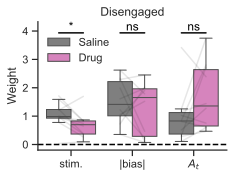

In [31]:
figsize = fig_size(n_cols=2)
ax = plot_paired_boxplot_GLMHMM_kernel(data[data.Label=='Disengaged'], drug=True, figsize=figsize, loc='upper left', bbox_to_anchor=(0, 0.95))
plt.title('Disengaged')

## Engaged

Covariate 0: t=-3.498, p=0.0067
Covariate 1: t=-0.611, p=0.5560
Covariate 2: t=-0.887, p=0.3981


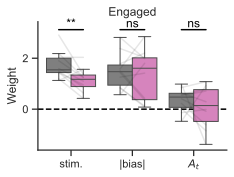

In [32]:
figsize = fig_size(n_cols=2)
ax = plot_paired_boxplot_GLMHMM_kernel(data[data.Label=='Engaged'], drug=True, figsize=figsize)
plt.title('Engaged')
ax.get_legend().remove()

# Save all notebook's figures

In [33]:
# # Whole notebook outputs (no input or prompt, only Markdown and figures)
# # As HTML
# !jupyter nbconvert notebook.ipynb --to html --no-input --no-prompt
# # As PDF
# !jupyter nbconvert notebook.ipynb --to pdf --no-input --no-prompt
#
# Export all figures
save_notebook_files(notebook_path='notebook_full_model.ipynb')

Saved 23 images to notebook_full_model_files/
